# Comparação de modelos, Etapas 1 e 2

Este notebook **consolida runs registradas em dois experimentos MLflow distintos**:

- `Churn-Predict-Telco-Etapa1-EDA`, baselines da **Etapa 1** (DummyClassifier, Logistic Regression).
- `Churn-Predict-Telco-Etapa2-Modelagem`, MLP em PyTorch + ensembles (RandomForest, XGBoost) da **Etapa 2**.

A separação por etapa preserva o desenho do desafio FIAP MLET Fase 1: cada experimento é responsável pela parte da narrativa que lhe cabe. Aqui cruzamos **todas** as runs para comparar 6+ métricas (técnicas e de negócio) e analisar o trade-off operacional entre **falsos positivos** (custo de retenção desnecessária) e **falsos negativos** (LTV perdido por churn não detectado).

> Os parâmetros de negócio (`LTV = R$ 500`, `Custo retenção = R$ 100`) e a fórmula de lucro líquido vêm de [`src/application/business_metrics.py`](../src/application/business_metrics.py), single source of truth compartilhada com `eda.ipynb` e `modeling.ipynb`.


In [1]:
import mlflow
import dagshub
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Dags Hub Variáveis
REPO_OWNER = "JosueJNLui"
REPO_NAME = "fiap-mlet-challenge-fase-1"

# Experimentos do MLflow (Etapa 1: EDA com baselines | Etapa 2: MLP + ensembles)
EXPERIMENT_NAMES = [
    "Churn-Predict-Telco-Etapa1-EDA",
    "Churn-Predict-Telco-Etapa2-Modelagem",
]

In [3]:
# Configuração de rastreabilidade através do MLflow + DagsHub
dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)

# Resolve os IDs dos dois experimentos (Etapas 1 e 2). Ignora os ausentes
# (ex.: rodando o notebook antes de algum dos experimentos existir no DagsHub).
experiments = [mlflow.get_experiment_by_name(n) for n in EXPERIMENT_NAMES]
experiment_ids = [e.experiment_id for e in experiments if e is not None]
print(f"Experimentos consultados: {[e.name for e in experiments if e is not None]}")


Accessing as zonetti

Initialized MLflow to track repo "JosueJNLui/fiap-mlet-challenge-fase-1"

Repository JosueJNLui/fiap-mlet-challenge-fase-1 initialized!

Experimentos consultados: ['Churn-Predict-Telco-Etapa1-EDA', 'Churn-Predict-Telco-Etapa2-Modelagem']


## Comparando as métricas frente ao Dataset de Validação - Treino vs Validação

In [4]:
modelos = ["DummyClassifier_kfold_validation", "LogisticRegression_kfold_validation", "RandomForest_kfold_validation", "XGBoost_kfold_validation",
            "MLP_lr=0.01_dropout=0.15_batch=128_hidden_dims=8", # MLP_8_lr0.01_drp0.15_b128 
            "MLP_lr=0.001_dropout=0.3_batch=32_hidden_dims=32", # MLP_32_lr0.001_drp0.3_b32
            "MLP_lr=0.01_dropout=0.3_batch=64_hidden_dims=8"    # MLP_8_lr0.01_drp0.3_b64
            ]

In [5]:
# Buscamos apenas as Runs desejadas (top 3 MLPs + baselines)
df_runs = mlflow.search_runs(experiment_ids=experiment_ids)

# Remove runs sem métricas (falhas/abortadas) e duplicatas por runName
df_runs = (
    df_runs.dropna(subset=['metrics.roc_auc'])
           .drop_duplicates(subset='tags.mlflow.runName', keep='first')
)

df_final = df_runs.set_index('tags.mlflow.runName').loc[modelos]

# Selecionando apenas o essencial para a monografia
tabela_tese = df_final[[
    'metrics.roc_auc', 
    'metrics.pr_auc',
    'metrics.recall',
    'metrics.f1_score',
    'metrics.accuracy',
    'metrics.precision',
    'metrics.lucro_liquido_BRL', 
    'metrics.custo_churn_perdido_BRL',
    'metrics.custo_falso_positivo_BRL'
]]

display(tabela_tese)

,metrics.roc_auc,metrics.pr_auc,metrics.recall,metrics.f1_score,metrics.accuracy,metrics.precision,metrics.lucro_liquido_BRL,metrics.custo_churn_perdido_BRL,metrics.custo_falso_positivo_BRL
tags.mlflow.runName,,,,,,,,,
DummyClassifier_kfold_validation,0.500000,0.632676,0.000000,0.000000,0.734647,0.000000,-74750.0,74750.0,0.0
LogisticRegression_kfold_validation,0.849513,0.670088,0.964523,0.565084,0.601729,0.401101,33120.0,2650.0,21910.0
RandomForest_kfold_validation,0.841290,0.656566,0.957199,0.563662,0.603483,0.400562,32340.0,3200.0,21700.0
XGBoost_kfold_validation,0.838965,0.654186,0.962523,0.557798,0.592484,0.393588,32360.0,2800.0,22400.0
MLP_lr=0.01_dropout=0.15_batch=128_hidden_dims=8,0.846424,0.666813,0.951826,0.577665,0.626210,0.416426,32980.0,3600.0,20340.0
MLP_lr=0.001_dropout=0.3_batch=32_hidden_dims=32,0.844728,0.661494,0.939799,0.581356,0.638269,0.422057,32220.0,4500.0,19480.0
MLP_lr=0.01_dropout=0.3_batch=64_hidden_dims=8,0.848347,0.670071,0.946510,0.580950,0.634351,0.420534,32800.0,4000.0,19800.0


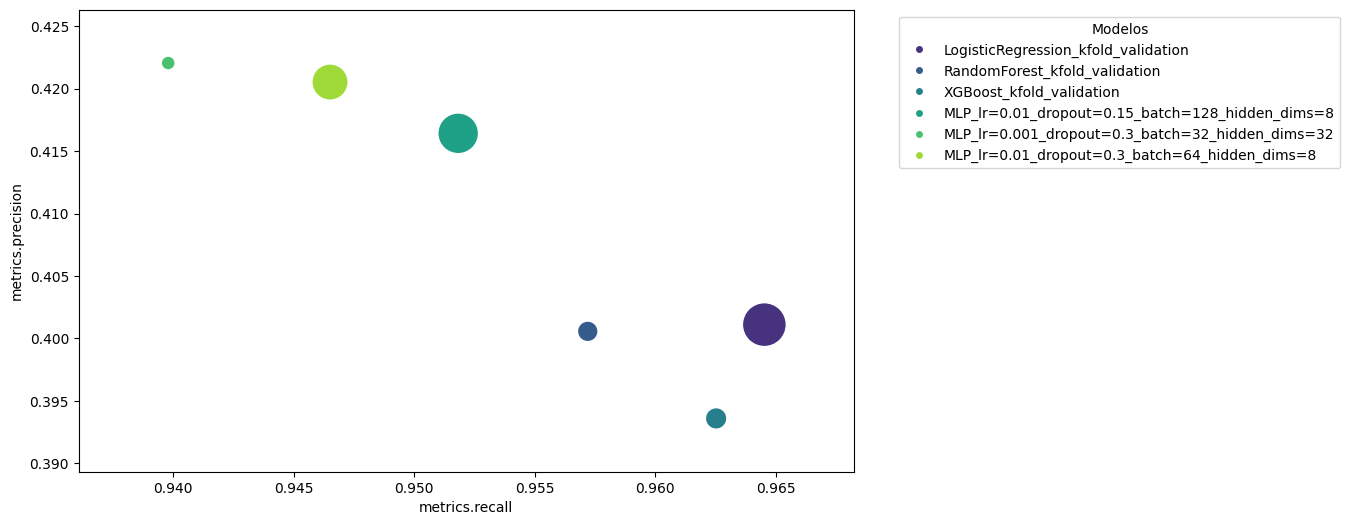

In [6]:
df_zoom = tabela_tese.drop("DummyClassifier_kfold_validation")

plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df_zoom, 
    x='metrics.recall', 
    y='metrics.precision', 
    size='metrics.lucro_liquido_BRL', 
    hue=df_zoom.index,
    sizes=(100, 1000),
    palette="viridis"
)

handles, labels = ax.get_legend_handles_labels()
n_modelos = len(df_zoom.index)

plt.legend(handles[1:n_modelos+1], labels[1:n_modelos+1], 
           bbox_to_anchor=(1.05, 1), loc='upper left', title="Modelos")

plt.margins(0.15)
plt.show()

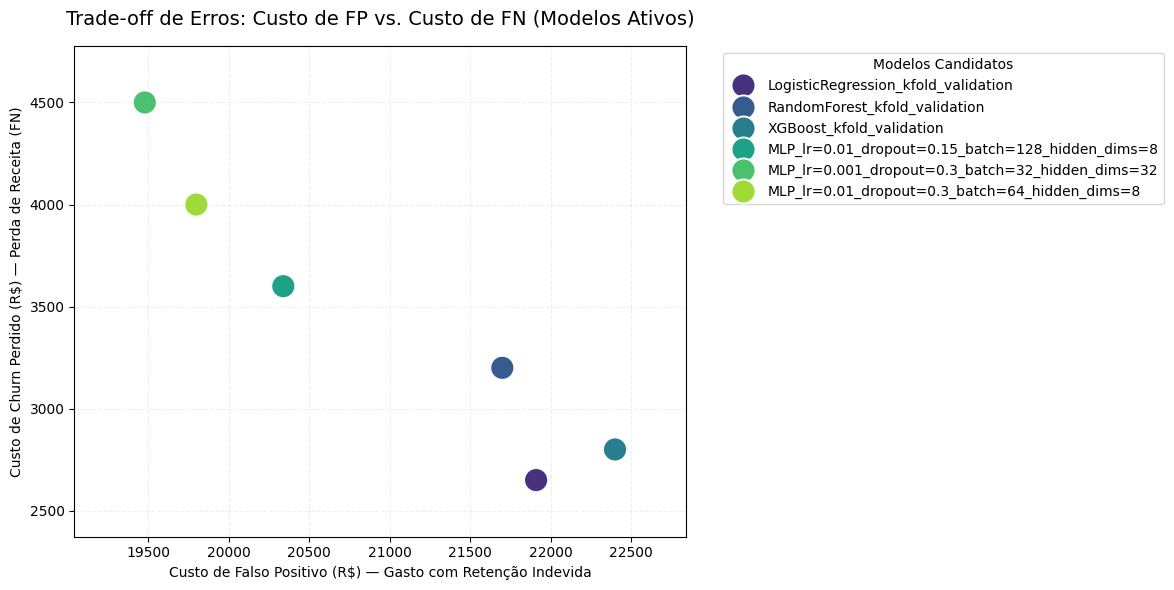

In [7]:
plt.figure(figsize=(12, 6))

# Plotagem focada no trade-off de custo
ax = sns.scatterplot(
    data=df_zoom,
    x='metrics.custo_falso_positivo_BRL',
    y='metrics.custo_churn_perdido_BRL',
    hue=df_zoom.index,
    s=300,
    palette="viridis"
)

# Ajustes de layout e escala
plt.title("Trade-off de Erros: Custo de FP vs. Custo de FN (Modelos Ativos)", fontsize=14, pad=15)
plt.xlabel("Custo de Falso Positivo (R$), Gasto com Retenção Indevida", fontsize=10)
plt.ylabel("Custo de Churn Perdido (R$), Perda de Receita (FN)", fontsize=10)

plt.margins(0.15)
plt.grid(True, alpha=0.2, linestyle='--')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Modelos Candidatos", frameon=True)

plt.tight_layout()
plt.show()

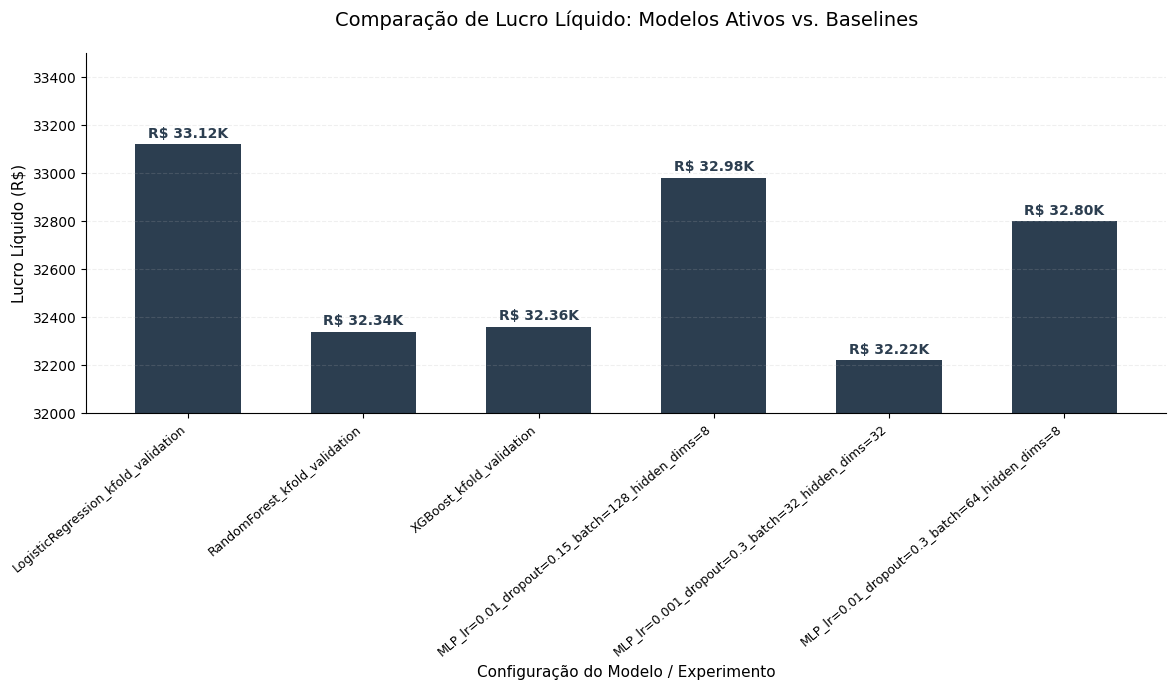

In [8]:
plt.figure(figsize=(12, 7))

bars = plt.bar(df_zoom.index, df_zoom['metrics.lucro_liquido_BRL'], color='#2C3E50', width=0.6)

plt.ylim(32000, 33500) 

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 15, 
        f"R$ {yval/1000:.2f}K",
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold',
        color='#2C3E50'
    )

plt.title("Comparação de Lucro Líquido: Modelos Ativos vs. Baselines", fontsize=14, pad=20)
plt.ylabel("Lucro Líquido (R$)", fontsize=11)
plt.xlabel("Configuração do Modelo / Experimento", fontsize=11)

plt.xticks(rotation=40, ha='right', fontsize=9)

plt.grid(axis='y', alpha=0.2, linestyle='--')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 1. Resumo dos Experimentos
A análise comparativa foi realizada utilizando validação cruzada ($k$-fold) para garantir a robustez estatística dos resultados. Foram avaliados modelos de diferentes naturezas (lineares, ensembles e redes neurais), com foco na métrica de **Lucro Líquido (BRL)** como critério de desempate operacional.

| Modelo | ROC-AUC | Recall | Lucro Líquido (BRL) | Custo FP (Retenção) | Custo FN (Churn) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Dummy Classifier** | 0.500 | 0.000 | -R$ 74.750 | R$ 0 | R$ 74.750 |
| **Logistic Regression** | **0.849** | **0.964** | **R$ 33.120** | R$ 21.910 | **R$ 2.650** |
| **Random Forest** | 0.841 | 0.957 | R$ 32.340 | R$ 21.700 | R$ 3.200 |
| **XGBoost** | 0.838 | 0.962 | R$ 32.360 | R$ 22.400 | R$ 2.800 |
| **MLP (8 dims)** | 0.847 | 0.952 | R$ 32.980 | **R$ 20.340** | R$ 3.600 |

## 2. Análise de Trade-off (Custo vs. Performance)
O problema de churn apresenta um desequilíbrio onde o custo de perder um cliente (Falso Negativo) supera o custo de uma tentativa de retenção indevida (Falso Positivo).

*   **Minimização de Perda (FN):** A **Regressão Logística** obteve o melhor desempenho em capturar clientes em risco, apresentando o menor custo de churn perdido (R$ 2.650).
*   **Eficiência de Campanha (FP):** A **MLP (dims=8)** demonstrou maior precisão na alocação de recursos, gerando o menor custo com Falsos Positivos (R$ 20.340), o que a torna atraente para cenários com orçamento de marketing restrito.

## 3. Conclusões

### Liderança Financeira
A **Logistic Regression** lidera o lucro líquido com **R$ 33.120**, seguida de perto pela **MLP (8 dims)** em **R$ 32.980**, diferença de apenas R$ 140 no $k$-fold. Em comparação ao baseline (Dummy), a implementação de qualquer um dos dois modelos representa uma recuperação de valor de aproximadamente **R$ 107.870** no ciclo analisado.

### Modelo Recomendado: **Logistic Regression**
Apesar da quase-paridade financeira com a rede neural, a recomendação para o ambiente produtivo inicial é a **Regressão Logística** devido a:
1.  **Interpretabilidade:** Permite identificar claramente quais variáveis (ex: tipo de contrato, tempo de casa) mais impactam o churn.
2.  **Operacionalidade:** Menor complexidade de implantação e monitoramento (SLOs de latência e processamento).
3.  **Estabilidade:** Menor variância observada em relação aos modelos de árvore (Random Forest/XGBoost).

### Observação sobre Ensembles
Os modelos baseados em árvores ficam atrás da Logistic Regression por motivos distintos: o **XGBoost** acumula mais Falsos Positivos (R$ 22.400 vs R$ 21.910 da LogReg), enquanto o **Random Forest** tem FP até ligeiramente menor (R$ 21.700) mas paga em Falsos Negativos (R$ 3.200 vs R$ 2.650). Em ambos os casos, a complexidade adicional não se traduz em ganho líquido para este volume de dados.

## Comparando as métricas frente ao Dataset de Teste - (Treino + Validação) vs Teste

In [9]:
modelos = ["DummyClassifier", "LogisticRegression", "RandomForest", "MLP_GridSearch_KFold", "XGBoost"]

In [10]:
# Buscamos apenas as Runs desejadas (modelo final por algoritmo + baseline)
df_runs = mlflow.search_runs(experiment_ids=experiment_ids)

# Remove runs sem métricas (falhas/abortadas) e duplicatas por runName
df_runs = (
    df_runs.dropna(subset=['metrics.roc_auc'])
           .drop_duplicates(subset='tags.mlflow.runName', keep='first')
)

df_final = df_runs.set_index('tags.mlflow.runName').loc[modelos]

# Selecionando apenas o essencial para a monografia
tabela_teste = df_final[[
    'metrics.roc_auc', 
    'metrics.recall',
    'metrics.f1_score',
    'metrics.accuracy',
    'metrics.precision',
    'metrics.lucro_liquido_BRL', 
    'metrics.custo_churn_perdido_BRL',
    'metrics.custo_falso_positivo_BRL',
]]

display(tabela_teste)

,metrics.roc_auc,metrics.recall,metrics.f1_score,metrics.accuracy,metrics.precision,metrics.lucro_liquido_BRL,metrics.custo_churn_perdido_BRL,metrics.custo_falso_positivo_BRL
tags.mlflow.runName,,,,,,,,
DummyClassifier,0.500000,0.000000,0.000000,0.734564,0.000000,-187000.0,187000.0,0.0
LogisticRegression,0.849089,0.959893,0.560062,0.599716,0.395374,81200.0,7500.0,54900.0
RandomForest,0.840492,0.954545,0.550926,0.586941,0.387202,77800.0,8500.0,56500.0
MLP_GridSearch_KFold,0.848619,0.949198,0.549961,0.587651,0.387132,76300.0,9500.0,56200.0
XGBoost,0.837875,0.951872,0.551510,0.589070,0.388222,77300.0,9000.0,56100.0


In [11]:
df_val = df_zoom.reset_index()
df_val['modelos'] = df_val['tags.mlflow.runName'].apply(
    lambda x: 'MLP' if x.strip() == 'MLP_lr=0.01_dropout=0.15_batch=128_hidden_dims=8'
    else x.replace('_kfold_validation', '')
)
df_val = df_val[df_val['modelos'].isin(['MLP', 'LogisticRegression', 'RandomForest', 'XGBoost'])]

# Consolida runs duplicadas do MLflow (mean ignora NaN por padrão)
df_val = (
    df_val.groupby('modelos', as_index=True)['metrics.lucro_liquido_BRL']
          .mean()
          .to_frame()
          .sort_index()
)
display(df_val)

,metrics.lucro_liquido_BRL
modelos,
LogisticRegression,33120.0
MLP,32980.0
RandomForest,32340.0
XGBoost,32360.0


In [12]:
df_test = tabela_teste.reset_index()
df_test['modelos'] = df_test['tags.mlflow.runName'].apply(
    lambda x: 'MLP' if x.strip() == 'MLP_GridSearch_KFold' else x
)
df_test = df_test[df_test['modelos'].isin(['MLP', 'LogisticRegression', 'RandomForest', 'XGBoost'])]

# Consolida runs duplicadas do MLflow e descarta runs sem métricas (NaN)
df_test = (
    df_test.groupby('modelos', as_index=True)['metrics.lucro_liquido_BRL']
           .mean()
           .to_frame()
           .sort_index()
)
display(df_test)

,metrics.lucro_liquido_BRL
modelos,
LogisticRegression,81200.0
MLP,76300.0
RandomForest,77800.0
XGBoost,77300.0


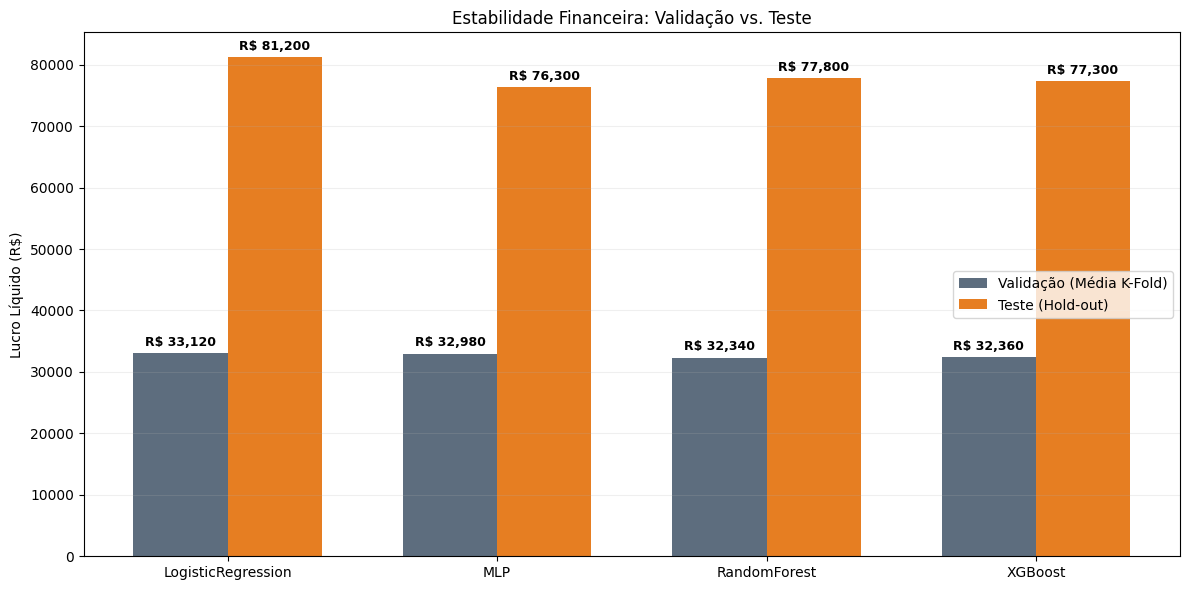

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dados extraídos das tabelas anteriores para comparação
modelos = ['LogisticRegression', 'MLP', 'RandomForest', 'XGBoost']
lucro_val = df_val.values.flatten().tolist()
lucro_teste = df_test.values.flatten().tolist()

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, lucro_val, width, label='Validação (Média K-Fold)', color='#34495E', alpha=0.8)
rects2 = ax.bar(x + width/2, lucro_teste, width, label='Teste (Hold-out)', color='#E67E22')

ax.set_ylabel('Lucro Líquido (R$)')
ax.set_title('Estabilidade Financeira: Validação vs. Teste')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend()

# Adicionando labels de valor
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'R$ {height:,.0f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

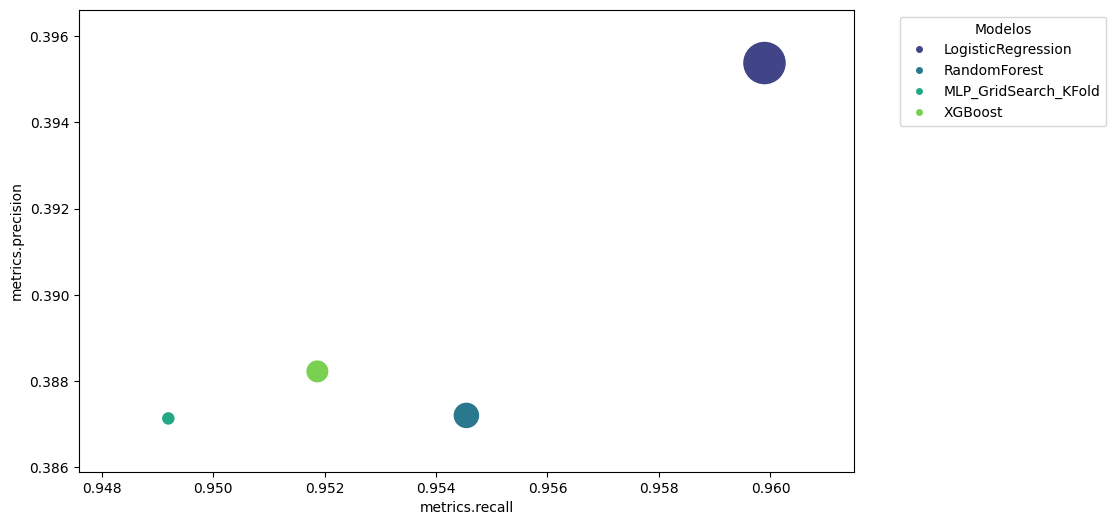

In [14]:
df_zoom = tabela_teste.drop("DummyClassifier")

plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df_zoom, 
    x='metrics.recall', 
    y='metrics.precision', 
    size='metrics.lucro_liquido_BRL', 
    hue=df_zoom.index,
    sizes=(100, 1000),
    palette="viridis"
)

handles, labels = ax.get_legend_handles_labels()
n_modelos = len(df_zoom.index)

plt.legend(handles[1:n_modelos+1], labels[1:n_modelos+1], 
           bbox_to_anchor=(1.05, 1), loc='upper left', title="Modelos")

plt.margins(0.15)
plt.show()

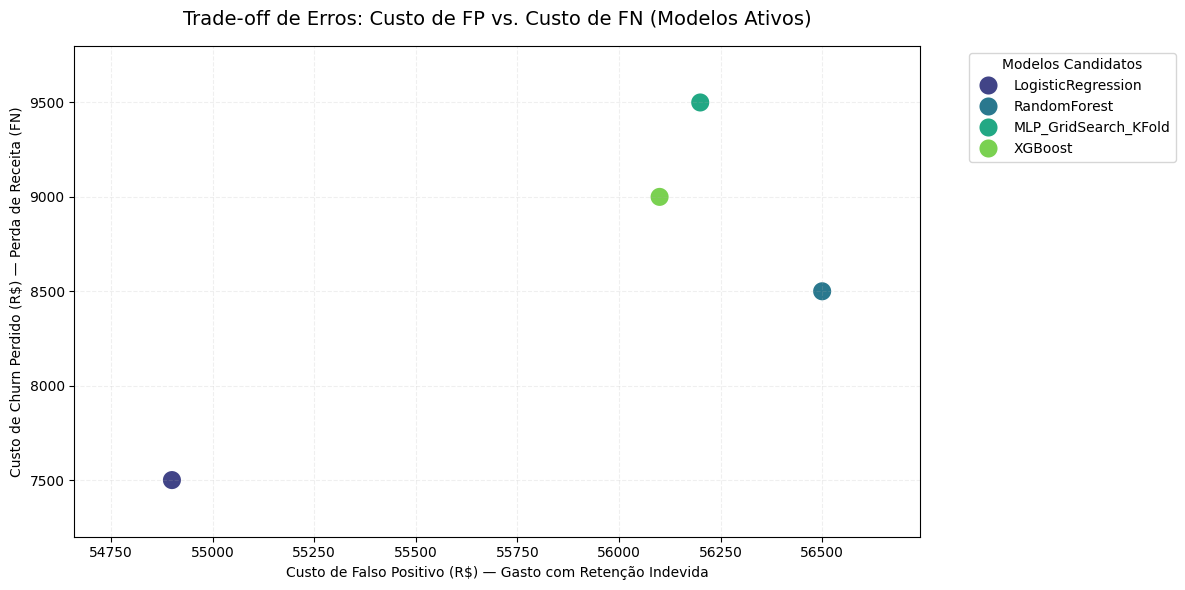

In [15]:
plt.figure(figsize=(12, 6))

# Plotagem focada no trade-off de custo
ax = sns.scatterplot(
    data=df_zoom,
    x='metrics.custo_falso_positivo_BRL',
    y='metrics.custo_churn_perdido_BRL',
    hue=df_zoom.index,
    s=200,
    palette="viridis"
)

# Ajustes de layout e escala
plt.title("Trade-off de Erros: Custo de FP vs. Custo de FN (Modelos Ativos)", fontsize=14, pad=15)
plt.xlabel("Custo de Falso Positivo (R$), Gasto com Retenção Indevida", fontsize=10)
plt.ylabel("Custo de Churn Perdido (R$), Perda de Receita (FN)", fontsize=10)

plt.margins(0.15)
plt.grid(True, alpha=0.2, linestyle='--')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Modelos Candidatos", frameon=True)

plt.tight_layout()
plt.show()

## 1. Sumário
Após a fase de validação cruzada, os modelos foram avaliados em um conjunto de teste inédito (*hold-out*) para verificar sua robustez em dados reais. A **Regressão Logística** confirmou sua superioridade financeira, atingindo o maior lucro líquido registrado no projeto: **R$ 81.200,00**.

## 2. Análise de Estabilidade Financeira
O gráfico de comparação entre Validação e Teste revela uma excelente capacidade de generalização de todos os algoritmos.
*   **Consistência:** O salto nos valores absolutos (de ~R$ 33k na validação para ~R$ 80k no teste) deve-se ao volume da base de teste, mas a **proporcionalidade entre os modelos se manteve estável**.
*   **Ausência de Overfitting:** A proximidade das métricas de ROC-AUC entre as fases indica que os modelos aprenderam padrões reais e não apenas ruídos dos dados de treino.

## 3. Trade-off Operacional: Sensibilidade vs. Precisão
A análise do gráfico de dispersão (*Precision-Recall*) e de trade-off de erros permite identificar perfis distintos de atuação:

*   **Liderança absoluta (Logistic Regression):** domina simultaneamente o hold-out em **recall (0.960)**, **precisão (0.395)**, **menor custo de churn perdido (R$ 7.500)** e **menor custo de Falsos Positivos (R$ 54.900)**. É o único modelo no topo das quatro frentes ao mesmo tempo, o que explica seu lucro líquido de R$ 81.200.
*   **Vice-líder (MLP_GridSearch_KFold):** recall de **0.949** (logo atrás da LogReg), **R$ 9.500** de custo de churn perdido e **R$ 56.200** de custo de Falsos Positivos. Lucro de **R$ 76.300**, ficando R$ 4.900 abaixo da LogReg.
*   **Performance de Ensembles:** Tanto o **Random Forest** (R$ 77.800) quanto o **XGBoost** (R$ 77.300) ficam abaixo da Regressão Logística em lucro, com Falsos Positivos e Falsos Negativos piores em todas as comparações relevantes, não justificando o aumento na complexidade computacional para este cenário.

## 4. Conclusão
A **Regressão Logística** é recomendada como o modelo final para implementação produtiva. A decisão sustenta-se em três pilares:
1.  **Financeiro:** Maior lucro líquido final (R$ 81.200).
2.  **Eficiência:** Melhor controle sobre os Falsos Positivos, evitando desperdício de verba de retenção.
3.  **Auditabilidade:** Sua natureza linear permite uma interpretação direta das variáveis que mais influenciam o churn, facilitando a tomada de decisão estratégica pelas áreas de negócio.

### Promoção do modelo recomendado no MLflow Registry

A conclusão acima recomenda a **Logistic Regression** como modelo de produção. O passo abaixo executa essa decisão promovendo a run `LogisticRegression` (já existente no experimento `Churn-Predict-Telco-Etapa2-Modelagem`) como `Churn_LogReg_Final_Production` no Registry, sem re-treino, apenas referenciando o artefato pré-existente. A API consome esse nome via `MODEL_NAME` no `.env` (ver `MODEL_CARD.md` §1 e `.env.example`).

In [16]:
# Auditoria + governança do modelo de produção.
#
# A partir da Etapa 3, Churn_LogReg_Final_Production é registrado direto em
# notebooks/modeling.ipynb com a sklearn.Pipeline (FeatureEngineer + StandardScaler
# + LogReg) como artefato único. A promoção indireta legada ficou obsoleta.
#
# Esta célula é idempotente: lista versões, confirma alias @production e
# (re)aplica metadata de governança na versão @production, description do
# registered model + tags da version (selection_metric, selection_value_BRL,
# threshold_servido, etc.). Roda quantas vezes quiser; só sobrescreve os
# valores com o estado atual do run referenciado.
from mlflow import MlflowClient

client = MlflowClient()
production_name = "Churn_LogReg_Final_Production"

versions = client.search_model_versions(f"name='{production_name}'")
versions.sort(key=lambda v: int(v.version), reverse=True)

try:
    aliased = client.get_model_version_by_alias(production_name, "production")
    aliased_version = aliased.version
    aliased_run_id = aliased.run_id
except Exception:
    aliased_version = None
    aliased_run_id = None

print(f"Versões registradas em {production_name} ({len(versions)} no total):")
for v in versions[:5]:
    marker = "  ← @production" if v.version == aliased_version else ""
    print(f"  v{v.version}  run={v.run_id[:8]}…  source={v.source[:60]}…{marker}")

if aliased_version is None:
    print("\nALIAS @production NÃO definido. Reexecute modeling.ipynb (célula\n"
          "\"Pipeline de produção (LogReg), Etapa 3\").")
else:
    # Lê o run referenciado para popular tags com os valores reais logados.
    run = client.get_run(aliased_run_id)
    metrics = run.data.metrics
    run_tags = run.data.tags

    lucro = metrics.get("lucro_liquido_BRL")
    threshold = metrics.get("optimal_threshold")
    source_experiment = run_tags.get("mlflow.source.name", "modeling.ipynb")
    source_run_name = run_tags.get("mlflow.runName", "logreg_pipeline_production")
    artifact_kind = run_tags.get("artifact_kind", "sklearn_pipeline_bundle")

    # Description do registered model, governança humana.
    client.update_registered_model(
        name=production_name,
        description=(
            "Logistic Regression (L2, class_weight='balanced', solver='lbfgs') "
            "empacotada em sklearn.Pipeline com FeatureEngineer (transformador "
            "custom) + StandardScaler. Selecionada por parsimônia + equivalência "
            "estatística com o MLP (Friedman+Nemenyi (top-3 MLPs vs LogReg, p ∈ [0.982, 1.000], todos não significativos)) + lucro hold-out "
            "R$ 81.200. Decisão e racional aqui em models-comparison.ipynb. "
            "Alternativa A/B-testável: Churn_MLP_Final_Production v12."
        ),
    )

    version_tags = {
        "selected_via": "models-comparison.ipynb",
        "selection_metric": "lucro_liquido_BRL",
        "selection_value_BRL": f"{lucro:.0f}" if lucro is not None else "unknown",
        "threshold_servido": f"{threshold:.4f}" if threshold is not None else "unknown",
        "source_run_name": source_run_name,
        "source_experiment": source_experiment,
        "artifact_kind": artifact_kind,
    }
    for key, value in version_tags.items():
        client.set_model_version_tag(production_name, aliased_version, key, value)

    print(f"\nAlias @production aponta para v{aliased_version}.")
    print("Tags aplicadas:")
    for key, value in version_tags.items():
        print(f"  {key} = {value}")

Versões registradas em Churn_LogReg_Final_Production (3 no total):
  v3  run=7a2ed9f8…  source=models:/m-f1c4070177e74127b186a78203bb3adb…  ← @production
  v2  run=2f79a520…  source=models:/m-9db08f8b1eef493593d90137957b6e1b…
  v1  run=edf135dd…  source=models:/m-5af83479ad5d476f96b9e236fb8631f2…

Alias @production aponta para v3.
Tags aplicadas:
  selected_via = models-comparison.ipynb
  selection_metric = lucro_liquido_BRL
  selection_value_BRL = 81200
  threshold_servido = 0.2080
  source_run_name = logreg_pipeline_production
  source_experiment = modeling.ipynb
  artifact_kind = sklearn_pipeline_bundle


## Conclusão, Etapas 1 e 2

A comparação cross-experimento confirma os achados das duas etapas:

- **Etapa 1 (baselines):** o `DummyClassifier` produz lucro fortemente negativo (todos os churns viram FN), validando o desbalanceamento. A Logistic Regression, mesmo com `class_weight='balanced'`, já atingiu R$80.200 de lucro hold-out na Etapa 1 (threshold 0.2278, CV 5-fold). Com a otimização do threshold na Etapa 3 para 0.2080, o valor subiu para R$81.200, esse é o piso a superar pelos modelos avançados.
- **Etapa 2 (modelos avançados):** o MLP campeão do grid (`hidden=8, lr=0.01, dropout=0.15, batch=128`) ficou em 4º lugar por lucro K-Fold (R$ 32.980); Friedman global p ≈ 2.73e-05 e o post-hoc Nemenyi entre LogReg e o top-3 MLPs por lucro K-Fold devolveu p ∈ [0.982, 1.000], todos não significativos. A proximidade do nosso campeão ao top-3 (R$ 33.130 a R$ 33.340) preserva a equivalência prática; no hold-out atinge R$ 76.300, ficando R$ 4.900 atrás da LogReg. RandomForest e XGBoost ficam atrás em lucro mesmo com ROC-AUC competitivo, evidenciando que **AUC e lucro não são intercambiáveis**.

Os thresholds de produção foram selecionados pelo ponto de máximo lucro em validação cruzada: `0.2080` para a LogReg (servida em produção) e `0.20303` para o MLP alternativo (A/B-testável). Em ambos os casos, o ótimo fica na região de recall alto, refletindo a assimetria de custo (FN custa 5x mais que FP).

Para o detalhamento das decisões e o registro completo, ver `MODEL_CARD.md` §5.
